# Week 11 - CIFAR with CNNs and Quantum Tomography

- Exercise 1: We use a convolutional neural network to classify images from CIFAR and look what is going on inside the network.

- Exercise 2: We train a neural network to fit the distribution of a quantum state from few measurements.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: Convolutional Neural Networks for CIFAR10


In this exercise, you will train a simple CNN to classify images from the CIFAR10 dataset.


## Exercise 1.1
Download the CIFAR10 dataset using `torchvision.datasets.CIFAR10`, and build the train and test dataloaders, setting the batch size to 32 and activating reshuffling at each epoch for the train data by setting `shuffle=True`. Visualize some images and their different color channels.
- What does the transform do?

In [2]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

training_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

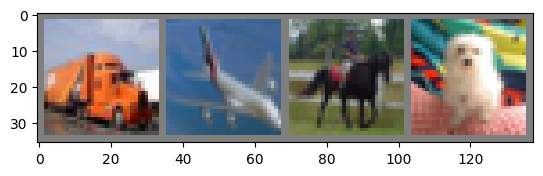

truck plane horse dog


In [3]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_dataloader)
images, labels = next(dataiter)

# Visualize a few images
imshow(torchvision.utils.make_grid(images[:4]))
print(' '.join(classes[labels[j]] for j in range(4)))

## Exercise 1.2

 Define a function returning a convolutional neural network built with `nn.Sequential`. Use a first layer of 6 convolutional channels with filter size 5, a max-pooling layer over a $2 \times 2$ window, a second convolutional layer made of 16 channels with filter size 5, another $2 \times 2$ max-pooling layer, two dense layers with 120 and 84 neurons respectively, and a final linear layer with 10 outputs.

 Use the `nn.Flatten()` operation if needed. You can also find convolutional layers in the pytorch documentation. 
 
 Bonus: What would be other ways to implement the same convolutional model?


In [4]:
def initialize_cnn():
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),  # 3→6 : 3 is RGB channels
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),  # 6→16
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Flatten(),  # Output: 16 * 5 * 5 = 400

        nn.Linear(16 * 5 * 5, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10)
    )
    return model

## Exercise 1.3

Using the cross-entropy loss and SGD with learning rate 0.01, train the model for 5 epochs. After training, compute the accuracy on the test set. Did your algorithm converge?

Bonus: If you are on colab, use the GPU. Compare the times -- did it help speed the process up? Don't forget to also put the batches on the GPU.

In [5]:
model = initialize_cnn()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
num_epochs = 5
losses = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_dataloader):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        losses.append(loss.item())
        if i % 100 == 99:    # print every 100 mini-batches
            print(f'Epoch [{epoch + 1}, {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

Epoch [1, 100] loss: 2.304
Epoch [1, 200] loss: 2.302
Epoch [1, 300] loss: 2.303
Epoch [1, 400] loss: 2.301
Epoch [1, 500] loss: 2.299
Epoch [1, 600] loss: 2.296
Epoch [1, 700] loss: 2.292
Epoch [1, 800] loss: 2.283
Epoch [1, 900] loss: 2.262
Epoch [1, 1000] loss: 2.240
Epoch [1, 1100] loss: 2.225
Epoch [1, 1200] loss: 2.192
Epoch [1, 1300] loss: 2.153
Epoch [1, 1400] loss: 2.120
Epoch [1, 1500] loss: 2.099
Epoch [2, 100] loss: 2.018
Epoch [2, 200] loss: 2.001
Epoch [2, 300] loss: 1.976
Epoch [2, 400] loss: 1.924
Epoch [2, 500] loss: 1.930
Epoch [2, 600] loss: 1.900
Epoch [2, 700] loss: 1.890
Epoch [2, 800] loss: 1.843
Epoch [2, 900] loss: 1.841
Epoch [2, 1000] loss: 1.841
Epoch [2, 1100] loss: 1.782
Epoch [2, 1200] loss: 1.787
Epoch [2, 1300] loss: 1.752
Epoch [2, 1400] loss: 1.733
Epoch [2, 1500] loss: 1.728


KeyboardInterrupt: 

In [ ]:
print('Finished Training')
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct / total} %')


Finished Training
Accuracy of the network on the 10000 test images: 49.43 %


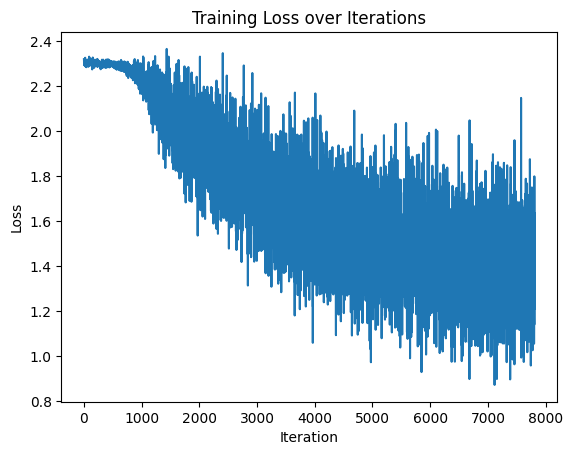

In [ ]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.show()

## Exercise 1.3 - Changing the optimizer

Making an analogy with a physical system, we can think of the negative gradient as a force moving a particle through parameter space, following Newton’s laws. Adding a momentum or inertia term, the optimization algorithm remembers the directions of the past gradients and continues to move in their direction. Mathematically,
$$
    v_t = \gamma v_{t-1} + \eta \nabla_\theta L(\theta_t)
$$
$$
    \theta_{t+1} = \theta_t - v_t,
$$
where $\gamma \in [0,1]$ is the momentum parameter, $\eta$ the learning rate, and $\theta$ the parameters of the model. Momentum helps the optimization dynamics gain speed in directions with persistent small gradients and suppresses oscillations. Repeat training, adding `momentum=0.9` to the SGD class.

- What is the effect of the momentum (compared to no momentum)? To understand, it helps to plot the loss curves.
- Bonus: Set the momentum value very high. What happens? Does that match your expectation?

Epoch [1, 100] loss: 2.298
Epoch [1, 200] loss: 2.199
Epoch [1, 300] loss: 2.047
Epoch [1, 400] loss: 1.923
Epoch [1, 500] loss: 1.812
Epoch [1, 600] loss: 1.762
Epoch [1, 700] loss: 1.678
Epoch [1, 800] loss: 1.627
Epoch [1, 900] loss: 1.624
Epoch [1, 1000] loss: 1.553
Epoch [1, 1100] loss: 1.536
Epoch [1, 1200] loss: 1.485
Epoch [1, 1300] loss: 1.490
Epoch [1, 1400] loss: 1.446
Epoch [1, 1500] loss: 1.435
Epoch [2, 100] loss: 1.431
Epoch [2, 200] loss: 1.411
Epoch [2, 300] loss: 1.353
Epoch [2, 400] loss: 1.361
Epoch [2, 500] loss: 1.380
Epoch [2, 600] loss: 1.363
Epoch [2, 700] loss: 1.303
Epoch [2, 800] loss: 1.327
Epoch [2, 900] loss: 1.287
Epoch [2, 1000] loss: 1.319
Epoch [2, 1100] loss: 1.267
Epoch [2, 1200] loss: 1.260
Epoch [2, 1300] loss: 1.274
Epoch [2, 1400] loss: 1.299
Epoch [2, 1500] loss: 1.271
Epoch [3, 100] loss: 1.175
Epoch [3, 200] loss: 1.182
Epoch [3, 300] loss: 1.223
Epoch [3, 400] loss: 1.177
Epoch [3, 500] loss: 1.181
Epoch [3, 600] loss: 1.170
Epoch [3, 700] l

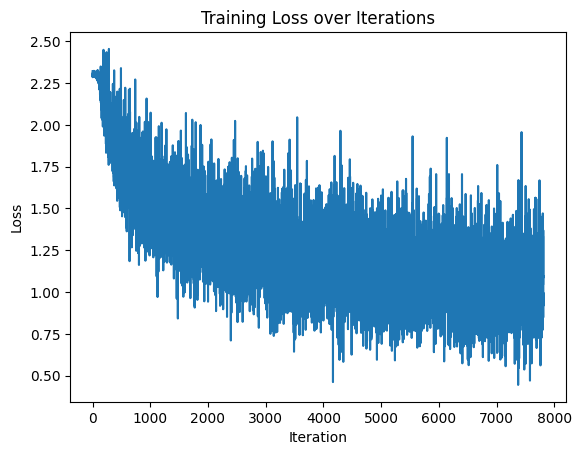

In [ ]:
model = initialize_cnn()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
num_epochs = 5
losses = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_dataloader):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        losses.append(loss.item())
        if i % 100 == 99:    # print every 100 mini-batches
            print(f'Epoch [{epoch + 1}, {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0
    
print('Finished Training')
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct / total} %')

plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.show()

## Exercise 1.4 - Feature Maps

We often argue that neural networks are black-boxes. We say that we do not understand what is going on inside and how they do their computations.

In fact, they are not completely black-box: We can look inside and we know *every multiplication or addition* that is happening to produce the final prediction. We just do not know a useful way to **interpret** these introspections macroscopically - there is no simple explanation that arrises directly from the matrix-multiplications.

One way to get a better insight, is to understand how the input looks after a single layer or looks from the perspective of a single neuron. E.g. for which pixel is the neuron activated high and for which low? This allows us to get an intuition which **features** activate the neuron.

**A) - Layers** Using `torch.fx`, (**f**eature e**x**traction) we can visualize these transformations of an input inside our neural network. For different input images, check the outputs of the first convolutional layer, of the first ReLU application, and of the first pooling layer.

In [ ]:
from torchvision.models.feature_extraction import get_graph_node_names
from torchvision.models.feature_extraction import create_feature_extractor

nodes, _ = get_graph_node_names(model)
print(nodes) # Prints the nn.Sequential layer names

feature_extractor = create_feature_extractor(
	model, return_nodes=['0', '1', '2']) # Outputs of first conv. layer, ReLU, and first pooling layer

['input', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']


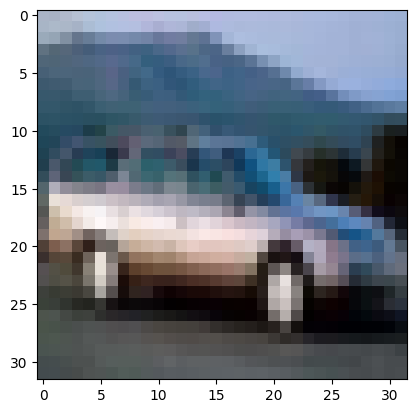

Layer: 0 | Output shape: torch.Size([1, 6, 28, 28])


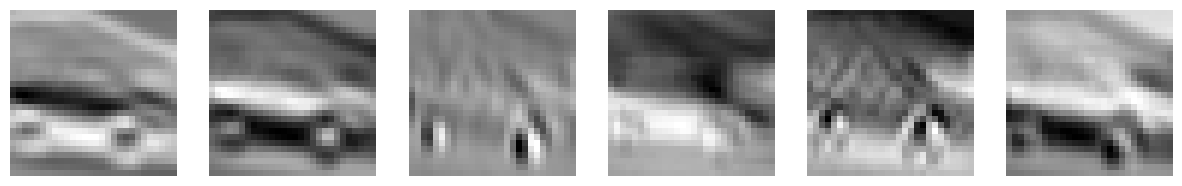

Layer: 1 | Output shape: torch.Size([1, 6, 28, 28])


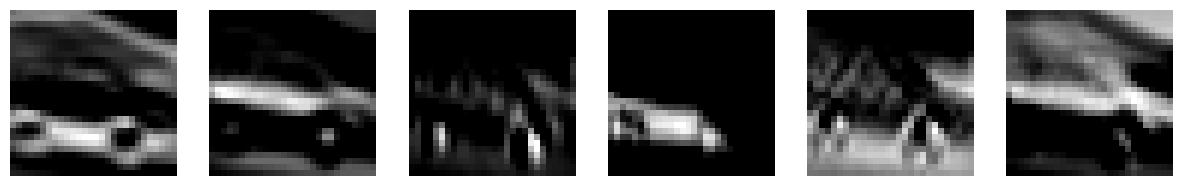

Layer: 2 | Output shape: torch.Size([1, 6, 14, 14])


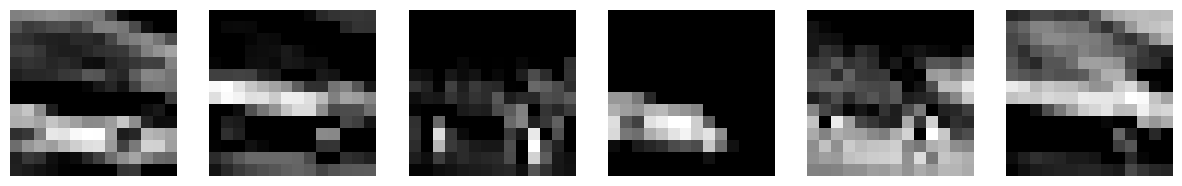

In [ ]:
dataloader = DataLoader(training_data, batch_size=32)

dataiter = iter(dataloader)
images, labels = next(dataiter)
id = 4
image = images[id]

out = feature_extractor(image.unsqueeze(0))

imshow(image)

# show the outputs after the given layers

for key, value in out.items():
    print(f"Layer: {key} | Output shape: {value.shape}")
    npimg = value.squeeze(0).detach().numpy()
    fig, axes = plt.subplots(1, min(6, npimg.shape[0]), figsize=(15, 5))
    for i in range(min(6, npimg.shape[0])):
        axes[i].imshow(npimg[i], cmap='gray')
        axes[i].axis('off')
    plt.show()

**B) - Neurons** Can we look at what a particular neuron reacts to? What are the features learned by deep models? A simple idea to visualize these features, called activation maximization, consists in looking for the input with bounded norm that maximizes the activation of a given neuron ($x^* = \arg \max_{x: \; \|x\|=1} h_i^{\ell}(x,\theta^*)$, where $h_i^\ell$ is the activation of the neuron $i$ at layer $\ell$ of a trained network). Open https://distill.pub/2017/feature-visualization/appendix and check how the neurons in different layers of the GoogLeNet network are specializing to recognize features with various complexity, from simple textures to meaningful semantic concepts!

# Exercise 2: Neural Networks for Quantum State Tomography

In this exercise you will train a neural network to fit the distribution of a quantum state from few measurements of it. Even though this problem has applications in physics, for the purpose of this exercise we will mainly consider it as a regression problem, without concerning us with the physics behind it.

> ⚠️ You should be able to solve the exercises without GPU acceleration, but feel free to add it if you want.

## Introducing the problem: Quantum State Tomography

We are given a dataset with $N$ samples $\{x_i,y_i \}_{i = 1, ..., N}$ where $x_i = \{0,1\}^{\mathtt{n\_spins}}$ is a binary string of length $\mathtt{n\_spins}$ and $y_i \in (0,1]$ is a  number. We have our regression problem.

But where is the data from? We are considering the case where the $x_i$ are the the possible outcomes of a measurement of a quantum state $\Psi$ and $y_i$ is the probability of observing outcome $x_i$.
Our goal is to train a neural network $f_\theta(x) = \hat{y}$ that approximates the original probability distribution. Specifically, for the set of possible outcomes $\{x_i\}$, the model should return a vector of probabilities corresponding to each outcome.


## Exercise 2.1: A fully connected network

For the purpose of this exercise, we give you a function that samples $N$ measurements from a quantum state along with their probabilities.

In [7]:
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

def get_data(n_spins):
    
    # Loads the data available in the .txt files we made available to you.
    
    if n_spins not in [8,12,16]:
        raise ValueError(f"The data for {n_spins} is not available.")
        
    numbers = [bin(i)[2:].zfill(n_spins) for i in range(2**n_spins)]
    xs = [[int(char) for char in string] for string in numbers]
    X = np.array(xs)
    
    Wstate = np.loadtxt(f"target_state_{n_spins}.txt")
    Y = np.abs(Wstate)**2
    
    # shuffle
    idx = np.random.permutation(range(len(Y)))
    
    return X[idx], Y[idx]

a) Load the data for `n_spins=16` and visualize the labels as a histogram. Visualize both `y` and `log(y)` in different plots. Which representation is more informative?

---

The histogram of the raw labels y is extremely peaked near zero. Since most quantum state probabilities are very small, the distribution is highly skewed and the histogram of y does not show much structure: almost all values appear collapsed in the first few bins close to 0.

In contrast, the histogram of \log(y) spreads these values over a much wider range. This representation reveals differences of several orders of magnitude between probabilities and shows a clear structure: it highlights the broad distribution and the separation between more and less likely configurations.

Therefore, the log-representation of the labels is significantly more informative, because it avoids the collapse of small probabilities and allows a clearer visualization of the underlying distribution.

---

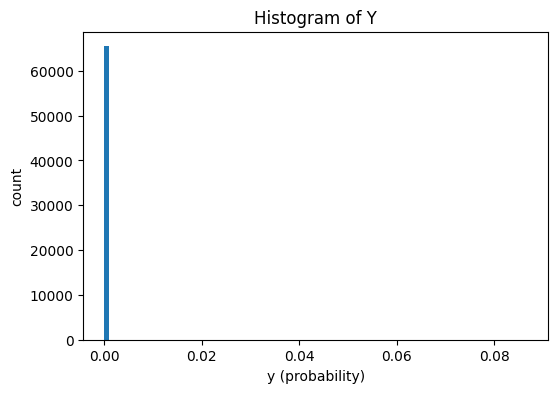

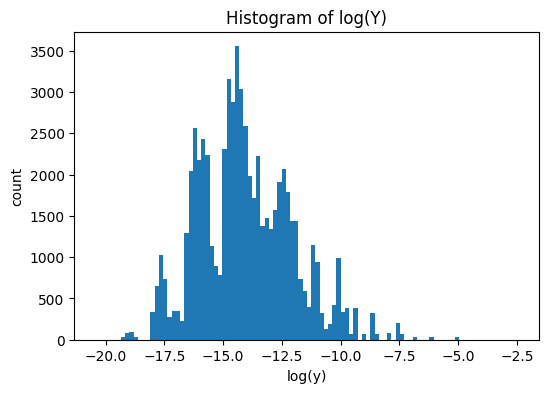

In [12]:
# --- Plot Y ---
plt.figure(figsize=(6,4))
plt.hist(Y, bins=100)
plt.xlabel("y (probability)")
plt.ylabel("count")
plt.title("Histogram of Y")
plt.show()

# --- Plot log(Y) ---
plt.figure(figsize=(6,4))
plt.hist(np.log(Y), bins=100)
plt.xlabel("log(y)")
plt.ylabel("count")
plt.title("Histogram of log(Y)")
plt.show()

b) We want to continue working with this datasets in two different forms, either without or with the log-transform of the labels : $\{x_i,y_i\}$ or $\{x_i,log(y_i)\}$. Then we want to train neural networks on this data using SGD. 

Complete the function `get_loaders`. Set `n_spins=12` and apply the log transform according to the normalize variable. Create a test, train and validation dataset using `TensorDataset`, the split should be done at (40%,20%,40%) of the original data. To prepare for training, wrap the new datasets in torch `DataLoaders` as you have seen in previous exercises. For training data loader, use a batch size 32 and use shuffling, for test and validation data loaders use the full batch and don't shuffle. 

In [14]:
def get_loaders(X, Y, normalize_log = False):
    
    n_spins = 12
   
    if normalize_log:
        Y = np.log(Y + 1e-10)
        Y = (Y - Y.mean()) / Y.std()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    Y_tensor = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)
    dataset = TensorDataset(X_tensor, Y_tensor)
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    train_loader, val_loader, test_loader = torch.utils.data.random_split(
        dataset, [train_size, val_size, test_size])
    
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_loaders(X, Y, normalize_log=True)

c) Define a general function `train` as given below that takes the test and train loaders, a learning rate and a model, a number of epochs and optionally a boolean `logging`equal to `True` by default and returns the train and test losses for every epoch, and the best test loss achieved overall. 

You are supposed to run SGD with the MSE loss. Print the progress of your training by printing the losses every epoch, if `logging==True`.

- I) In the course of your code you will use the line `optimizer.zero_grad()`. Explain briefly what happens when you call this function, and when and why you need to call it.

- II)  Explain why we previously needed to activate the batches and shuffling for the training dataloader. 

- III) When a dataloader is used several times for several epochs, is the data shuffled in the same order every time?

*`Answers:`* 
During backpropagation, PyTorch accumulates gradients in the .grad attributes of all parameters.
This means that each call to loss.backward() adds new gradients to the previous ones.

optimizer.zero_grad() clears (sets to zero) all gradients stored in the model’s parameters.

Why do we need it?

Because if we didn’t reset the gradients at each training step,
the optimizer would update parameters using the sum of all past gradients, which would make training behave incorrectly.

Shuffling

Shuffling ensures that every epoch presents the samples in a different order.

This is important because:
	•	It prevents the network from learning the order of the training set.
	•	It avoids cycles or biases caused by always seeing the same sequence of examples.
	•	It improves generalization and optimization.

Without shuffling, the model might overfit patterns in the ordering rather than in the data.

In [23]:
def train(train_loader, test_loader, lr, model, n_epochs, logging=True, tol=1e-2):
    
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    for epoch in range(n_epochs):
        model.train()
        running_train_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)
            if running_train_loss < tol:
                print("Early stopping: Loss is too small.")
                return train_losses, test_losses, best_test_loss
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_test_loss = 0.0
        with torch.no_grad():
            for inputs, targets in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_test_loss += loss.item() * inputs.size(0)
        epoch_test_loss = running_test_loss / len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss

        if logging:
            print(f'Epoch {epoch+1}/{n_epochs}, Train Loss: {epoch_train_loss:.6f}, Test Loss: {epoch_test_loss:.6f}')
    
    return train_losses, test_losses, best_test_loss

d) Test your function by training a 1 hidden layer fully connected network with ReLU activations. You will choose the hyperparameters: `n_epochs` to train and the `learning rate`. You can keep the number of `hidden_neurons=16` fixed for the moment. Hint: You should not need to use more than 2000 epochs in your explorations...

Write the code to train and visualize the test and train losses with a log-sacle on the y-axis.
It is now your turn to play.

Choose `lr=0.1`, `n_epochs=100` and `hidden_neurons=16`. Train 10 models with these hyperparameters and observe their learning curves. We would expect the learning curves of the 10 different models to be different because every time you define a new model, the weights are initialized randomly and the SGD optimizer will go over the batches in a different order. 

Describe what differences and similarities you observe. How could you change (some of) the hyperparameters so that the runs are more similar, i.e. the loss curve is less strongly dependent on the initialization?

*`Answer:`* 

In [25]:
# -------------------------
# TRAIN 10 MODELS
# -------------------------

n_spins = 12
X, Y = get_data(n_spins)
train_loader, val_loader, test_loader = get_loaders(X, Y, normalize_log=True)

n_runs = 10
all_train_curves = []
all_test_curves = []

for i in range(n_runs):

    model = nn.Sequential(
        nn.Linear(n_spins, 16),
        nn.ReLU(),
        nn.Linear(16, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

    train_losses, test_losses, best_loss = train(
        train_loader, test_loader,
        lr=0.1, model=model, n_epochs=100, logging=False,
        tol=1e-2
    )

    print(f"Run {i+1}/{n_runs}, Best Test Loss: {best_loss:.6f}")

    all_train_curves.append(train_losses)
    all_test_curves.append(test_losses)


# -------------------------
# PLOTS
# -------------------------

plt.figure(figsize=(8,5))
for curve in all_train_curves:
    plt.plot(curve, alpha=0.6)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Train loss (log scale)")
plt.title("Training loss for 10 runs")
plt.show()

plt.figure(figsize=(8,5))
for curve in all_test_curves:
    plt.plot(curve, alpha=0.6)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Test loss (log scale)")
plt.title("Test loss for 10 runs")
plt.show()

Run 1/10, Best Test Loss: 1.686726


e) Choose some parameters that reliably give you good models even if you restart the training . If you get a test loss around 0.01 you can stop training. 

*`Answer:`* ..

In [ ]:
n_spins = 12
X, Y = get_data(n_spins)
train_loader, val_loader, test_loader = get_loaders(X, Y, normalize_log=True)

n_runs = 10
all_train_curves = []
all_test_curves = []

for i in range(n_runs):

    model = nn.Sequential(
        nn.Linear(n_spins, 16),
        nn.ReLU(),
        nn.Linear(16, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

    train_losses, test_losses, best_loss = train(
        train_loader, test_loader,
        lr=0.01, model=model, n_epochs=128, logging=False,
        tol = 1e-2
    )

    print(f"Run {i+1}/{n_runs}, Best Test Loss: {best_loss:.6f}")

    all_train_curves.append(train_losses)
    all_test_curves.append(test_losses)

# -------------------------
# PLOTS
# -------------------------

plt.figure(figsize=(8,5))
for curve in all_train_curves:
    plt.plot(curve, alpha=0.6)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Train loss (log scale)")
plt.title("Training loss for 10 runs")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
for curve in all_test_curves:
    plt.plot(curve, alpha=0.6)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Test loss (log scale)")
plt.title("Test loss for 10 runs")
plt.grid()
plt.show()

TypeError: train() got an unexpected keyword argument 'tol'

f) For the previous model that you liked, plot the histogram of the distribution again with the log transform, for test data. Also plot the predicted and ground truth values against each other. Are you satisfied with the match?

*`Answer:`* ...

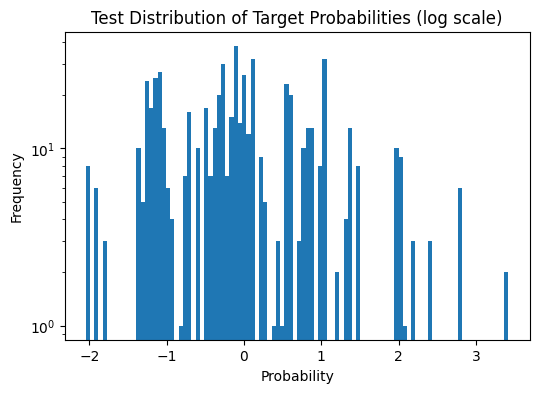

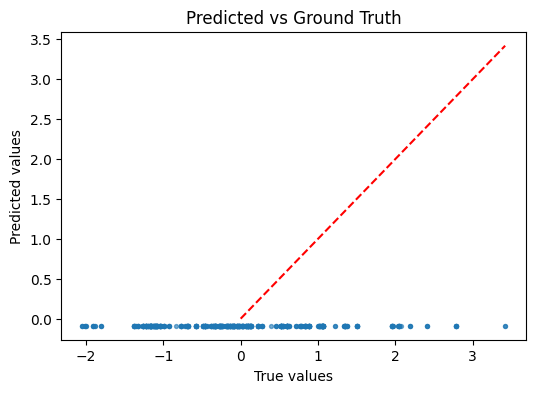

In [18]:
Y_test = []
X_test = []
for inputs, targets in test_loader:
    X_test.append(inputs.numpy())
    Y_test.append(targets.numpy())
X_test = np.vstack(X_test)
Y_test = np.vstack(Y_test).squeeze()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Histogram of true test labels (log scale)
plt.figure(figsize=(6,4))
plt.hist(Y_test, bins=100)
plt.yscale('log')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Test Distribution of Target Probabilities (log scale)')
plt.show()

# Predictions
Y_pred = model(X_test_tensor).detach().numpy()

# Scatter plot: predicted vs. true
plt.figure(figsize=(6,4))
plt.scatter(Y_test, Y_pred, s=8, alpha=0.6)
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Predicted vs Ground Truth')
plt.plot([0, max(Y_test)], [0, max(Y_test)], 'r--')  # diagonal line
plt.show()

## Exercise 2.2: Exploring alternative architectures  and losses

You have found a model that works! But can you make it more efficient?

a) A linear regression model would for example use fewer parameters. Try the model and based on your experiment argue that it is less suitable for this task than the fully connected neural network.

*`Answer:`* 
In practice, the model performed much worse:
	•	The training and test losses were significantly higher (typically well above 0.1, compared to ~0.01 for the neural network).
	•	The predicted vs. true values showed a very weak correlation, with the linear model unable to approximate the highly nonlinear structure in the data.
	•	The output distribution was also poorly matched: the linear model tended to predict values in a narrow range and never reproduced the heavy-tailed distribution of the labels.

In [ ]:
# your code here

b) If a linear regression does not work, maybe you can fine-tune the number of hidden neurons. Select 5 different values of the hidden neurons `[2,8,16,32,64]` and train those models. Use at max 500 epochs to train every model and a learning rate of 0.01. In reality you would optimize the learning rate for each architecture and you can still do so if you wish, but to save you time we do not require this. After the models are trained, select the best one based on the best test loss. 

Estimate the loss you can expect on the model that you just selected on a fresh data sample, that has not been seen in the process of selecting this model. 

*`Answer:`* ...

In [ ]:
# -------------------------
# TRAIN 10 MODELS
# -------------------------

n_spins = 12
X, Y = get_data(n_spins)
train_loader, val_loader, test_loader = get_loaders(X, Y, normalize_log=True)

hidden_neuron = [2,8,16,32,64]
all_train_curves = []
all_test_curves = []

for hidden in hidden_neuron:

    model = nn.Sequential(
        nn.Linear(n_spins, hidden),
        nn.ReLU(),
        nn.Linear(hidden, hidden),
        nn.ReLU(),
        nn.Linear(hidden, 1)
    )

    train_losses, test_losses, best_loss = train(
        train_loader, test_loader,
        lr=0.1, model=model, n_epochs=100, logging=False,
        tol=1e-4
    )

    print(f"Run for {hidden} hidden neurons, Best Test Loss: {best_loss:.6f}")

    all_train_curves.append(train_losses)
    all_test_curves.append(test_losses)


# -------------------------
# PLOTS
# -------------------------

plt.figure(figsize=(8,5))
for curve in all_train_curves:
    plt.plot(curve, alpha=0.6)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Train loss (log scale)")
plt.title("Training loss for 10 runs")
plt.show()

plt.figure(figsize=(8,5))
for curve in all_test_curves:
    plt.plot(curve, alpha=0.6)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Test loss (log scale)")
plt.title("Test loss for 10 runs")
plt.show()

c) Now you want to see what difference the log transformation we applied at the very beginning makes. Train a model on the plain data and compare the models prediction again both via the histogram of y-values and the scatterplot between the predicted and true y, in the log transform. What did the non-log transformed model learn and why?

*`Answer:`* ...

In [ ]:
# your code here